In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import os
import sys
import altair as alt

In [3]:
### labeling and binning evaluation of a batch of samples contained in a "data" directory
### the script will generate a "results" directory containing the results of the evaluation

In [175]:
base_dir = "/home/sgro"
input_dir = "/dataset"
cut_100_results = "/pbf-star-out-100"
cut_0_results = "/pbf-star-out"
output_dir = "/results"

cuts = [0,100]

pbf_graphs = ['u','s', 'psm.u', 'psm.s']

eval_string = {}
for x in cuts:
    for y in pbf_graphs:
        eval_string.update({f"{str(x) + '.pbf.' + y}": []})
print(eval_string)
eval_string.update({"100.pbf.u": None})
eval_string.update({"100.pbf.s": None})


stat_map = {"prec": [], "rec": [], "f1": []}
stat_tests = {}
for test in eval_string.keys():
    stat_tests.update({test: stat_map})
print(stat_tests)

dataset = set()
# iterate over files in input_dir and create a sample list
for filename in os.listdir(base_dir + input_dir):
    if filename.endswith(".gz"):
        dataset.update({filename[0:-9]: {}})
print(dataset)
print(len(dataset), " number of samples, of which")
# divide samples by their type, i.e. their first 4 characters
sample_types = set()
for sample in dataset:
    sample_types.update({sample[0:4]})
print(sample_types)
# count the samples for each type
sample_count = {}
for sample_type in sample_types:
    sample_count.update({sample_type: 0})
for sample in dataset:
    sample_count[sample[0:4]] += 1
print(sample_count)

# filter dataset into dataste_supported including only the samples with the supported types that are eclo efae ecol abau kpne
dataset_supported = set()
supported_types = ["efae", "ecol", "abau", "kpne"]
for sample in dataset:
    if sample[0:4] in supported_types:
        dataset_supported.update({sample: {}})
print(dataset_supported)
print(len(dataset_supported), " number of supported samples, of which")
# divide supported samples by their type, i.e. their first 4 characters
sample_types_supported = set()
for sample in dataset_supported:
    sample_types_supported.update({sample[0:4]})
# print(sample_types_supported)
# count the supported samples for each type
sample_count_supported = {}
for sample_type in sample_types_supported:
    sample_count_supported.update({sample_type: 0})
for sample in dataset_supported:
    sample_count_supported[sample[0:4]] += 1
print(sample_count_supported)
# extract the list of supported samples
supported_samples = list(dataset_supported)
# remove the species name from the sample name
for i in range(len(supported_samples)):
    supported_samples[i] = supported_samples[i][5:]
print(supported_samples)



{'0.pbf.u': [], '0.pbf.s': [], '0.pbf.psm.u': [], '0.pbf.psm.s': [], '100.pbf.u': [], '100.pbf.s': [], '100.pbf.psm.u': [], '100.pbf.psm.s': []}
{'0.pbf.u': {'prec': [], 'rec': [], 'f1': []}, '0.pbf.s': {'prec': [], 'rec': [], 'f1': []}, '0.pbf.psm.u': {'prec': [], 'rec': [], 'f1': []}, '0.pbf.psm.s': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.u': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.s': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.psm.u': {'prec': [], 'rec': [], 'f1': []}, '100.pbf.psm.s': {'prec': [], 'rec': [], 'f1': []}}
{'saur-SAMN03255451', 'kpne-SAMN16357471', 'saur-SAMN03255487', 'ecol-SAMN04014852', 'saur-SAMN03255453', 'kpne-SAMN03996301', 'saur-SAMN03996304', 'kpne-SAMN16357460', 'ehor-SAMN16357576', 'saur-SAMN03255458', 'kpne-SAMN16357449', 'ehor-SAMN16357247', 'saur-SAMN03255464', 'saur-SAMN03255474', 'saur-SAMN03255466', 'saur-SAMN03255469', 'ecol-SAMN02991226', 'kpne-SAMN16357453', 'kpne-SAMN16357466', 'kpne-SAMEA3357223', 'kpne-SAMN16357451', 'ecol-SAMN04014856',

In [176]:
plasgraph_dataset = "/home/sgro/dataset"

preprocessed = "/home/sgro/plas-out"
preprocessed_100 = "/home/sgro/plas-out-100"

results_pangenome = "/home/sgro/pbf-star-out"
results_pangenome_100 = "/home/sgro/pbf-star-out-100"
results_assemblies = "/home/sgro/pbf-assemblies-out/"

pangenome_eval = "/home/sgro/blast-0"
pangenome_eval_100 = "/home/sgro/blast-100"
asm_eval = "/home/sgro/blast-asm"

In [177]:
# divide files inside pangenome_eval into .plaseval.txt and stats.txt
plaseval_files = set()
stats_files = set()
for filename in os.listdir(pangenome_eval):
    if filename.endswith(".plaseval.txt"):
        plaseval_files.update({filename})
    elif filename.endswith("stats.txt"):
        stats_files.update({filename})

In [178]:
# divide files inside pangenome_eval_100 into .plaseval.txt and stats.txt
plaseval_files_100 = set()
stats_files_100 = set()
for filename in os.listdir(pangenome_eval_100):
    if filename.endswith(".plaseval.txt"):
        plaseval_files_100.update({filename})
    elif filename.endswith("stats.txt"):
        stats_files_100.update({filename})


In [179]:
# divide files inside asm_eval into .plaseval.txt and stats.txt
asm_files = set()
asm_stats_files = set()
for filename in os.listdir(asm_eval):
    if filename.endswith(".plaseval.txt"):
        asm_files.update({filename})
    elif filename.endswith("stats.txt"):
        asm_stats_files.update({filename})
        

In [180]:
# filter the supported samples in asm_files, pangenome_eval and pangenome_eval_100
plaseval_files_supported = set()
for sample in supported_samples:
    for filename in plaseval_files:
        if sample in filename:
            plaseval_files_supported.update({filename})
plaseval_files_100_supported = set()
for sample in supported_samples:
    for filename in plaseval_files_100:
        if sample in filename:
            plaseval_files_100_supported.update({filename})
            
asm_files_supported = set()
for sample in supported_samples:
    for filename in asm_files:
        if sample in filename:
            asm_files_supported.update({filename})
    

In [181]:
# filter the supported samples in asm_stats_files, stats_files and stats_files_100
stats_files_supported = set()
for sample in supported_samples:
    for filename in stats_files:
        if sample in filename:
            stats_files_supported.update({filename})
stats_files_100_supported = set()
for sample in supported_samples:
    for filename in stats_files_100:
        if sample in filename:
            stats_files_100_supported.update({filename})
asm_stats_files_supported = set()
for sample in supported_samples:
    for filename in asm_stats_files:
        if sample in filename:
            asm_stats_files_supported.update({filename})



In [182]:
# extract id from asm_files_supported
asm_ids = set()
for filename in asm_files_supported:
    asm_ids.update({filename[0:12]})
# print(asm_ids)
# extract id from plaseval_files_supported
plaseval_ids = set()
for filename in plaseval_files_supported:
    plaseval_ids.update({filename[0:12]})
# print(plaseval_ids)
# extract id from plaseval_files_100_supported
plaseval_ids_100 = set()
for filename in plaseval_files_100_supported:
    plaseval_ids_100.update({filename[0:12]})
# print(plaseval_ids_100)

# extract the list of common ids between asm_ids and plaseval_ids  and plaseval_ids_100
common_ids = set()
for id in asm_ids:
    if id in plaseval_ids and id in plaseval_ids_100:
        common_ids.update({id})
print(common_ids)
print(len(common_ids), " number of common ids")

{'SAMN07312488', 'SAMD00056131', 'SAMN16357458', 'SAMN03024583', 'SAMN03996301', 'SAMN16357448', 'SAMN11056344', 'SAMN16357471', 'SAMN16357453', 'SAMN16357457', 'SAMN16357455', 'SAMN16357205', 'SAMN16357459', 'SAMN03024573', 'SAMN16357460', 'SAMN16357462', 'SAMN04014860', 'SAMEA3357010', 'SAMN11056346', 'SAMN07312490', 'SAMN02786856', 'SAMN16357501', 'SAMN04014852', 'SAMN16357470', 'SAMN16357452', 'SAMN16357449', 'SAMN04014856', 'SAMEA3357272', 'SAMEA3357043', 'SAMN02991226', 'SAMN16357450', 'SAMN07312483', 'SAMN04014847', 'SAMN16357468', 'SAMN16357456', 'SAMN16357467', 'SAMEA3357077', 'SAMN10163228', 'SAMEA3357268', 'SAMN16357465', 'SAMN11056345', 'SAMN16357454', 'SAMN16357451', 'SAMN10163190', 'SAMN16357464'}
45  number of common ids


In [183]:
# from the common ids extract the list of files in asm_files_supported, plaseval_files_supported and plaseval_files_100_supported
asm_files_common = set()
plaseval_files_common = set()
plaseval_files_100_common = set()
for id in common_ids:
    for filename in asm_files_supported:
        if id in filename:
            asm_files_common.update({filename})
    for filename in plaseval_files_supported:
        if id in filename:
            plaseval_files_common.update({filename})
    for filename in plaseval_files_100_supported:
        if id in filename:
            plaseval_files_100_common.update({filename})
print(len(asm_files_common))
print(len(plaseval_files_common))
print(len(plaseval_files_100_common))
print(asm_files_common)

# from the common ids extract the list of files in asm_stats_files_supported, stats_files_supported and stats_files_100_supported
asm_stats_files_common = set()
stats_files_common = set()
stats_files_100_common = set()
for id in common_ids:
    for filename in asm_stats_files_supported:
        if id in filename:
            asm_stats_files_common.update({filename})
    for filename in stats_files_supported:
        if id in filename:
            stats_files_common.update({filename})
    for filename in stats_files_100_supported:
        if id in filename:
            stats_files_100_common.update({filename})
print(len(asm_stats_files_common))
print(len(stats_files_common))
print(len(stats_files_100_common))
print(asm_stats_files_common)


87
90
90
{'SAMEA3357268.pbf.ske.plaseval.txt', 'SAMN07312488.pbf.ske.plaseval.txt', 'SAMN07312483.pbf.ske.plaseval.txt', 'SAMN11056346.pbf.ske.plaseval.txt', 'SAMN16357205.pbf.ske.plaseval.txt', 'SAMN04014856.pbf.uni.plaseval.txt', 'SAMN11056345.pbf.uni.plaseval.txt', 'SAMN16357457.pbf.uni.plaseval.txt', 'SAMN04014852.pbf.uni.plaseval.txt', 'SAMEA3357077.pbf.uni.plaseval.txt', 'SAMN16357459.pbf.ske.plaseval.txt', 'SAMD00056131.pbf.uni.plaseval.txt', 'SAMN10163228.pbf.uni.plaseval.txt', 'SAMN03996301.pbf.uni.plaseval.txt', 'SAMN07312490.pbf.uni.plaseval.txt', 'SAMN07312488.pbf.uni.plaseval.txt', 'SAMN16357464.pbf.ske.plaseval.txt', 'SAMN16357462.pbf.uni.plaseval.txt', 'SAMN04014847.pbf.uni.plaseval.txt', 'SAMEA3357268.pbf.uni.plaseval.txt', 'SAMEA3357010.pbf.uni.plaseval.txt', 'SAMN02786856.pbf.uni.plaseval.txt', 'SAMN16357449.pbf.ske.plaseval.txt', 'SAMN16357455.pbf.uni.plaseval.txt', 'SAMN07312483.pbf.uni.plaseval.txt', 'SAMN16357450.pbf.uni.plaseval.txt', 'SAMN02991226.pbf.ske.plasev

In [184]:
# divide files in asm_files_common into 2 groups, one containing the files with the string ".u." and the other with the string ".s."
asm_files_common_u = set()
asm_files_common_s = set()
for filename in asm_files_common:
    if ".uni." in filename:
        asm_files_common_u.update({filename})
    elif ".ske." in filename:
        asm_files_common_s.update({filename})
print(len(asm_files_common_u))
print(len(asm_files_common_s))

# divide files in plaseval_files_common into 2 groups, one containing the files with the string ".u." and the other with the string ".s."
plaseval_files_common_u = set()
plaseval_files_common_s = set()
for filename in plaseval_files_common:
    if ".u." in filename:
        plaseval_files_common_u.update({filename})
    elif ".s." in filename:
        plaseval_files_common_s.update({filename})
print(len(plaseval_files_common_u))
print(len(plaseval_files_common_s))

# divide files in plaseval_files_100_common into 2 groups, one containing the files with the string ".u." and the other with the string ".s."
plaseval_files_common_100_u = set()
plaseval_files_common_100_s = set()

for filename in plaseval_files_100_common:
    if ".u." in filename:
        plaseval_files_common_100_u.update({filename})
    elif ".s." in filename:
        plaseval_files_common_100_s.update({filename})
print(len(plaseval_files_common_100_u))
print(len(plaseval_files_common_100_s))





44
43
45
45
45
45


In [266]:
# for asm_files_common_u, plaseval_files_common_u and plaseval_files_common_100_u
# open the files and extract the values of prec, rec and f1

eval_string_stats = {}
for x in cuts:
    for y in pbf_graphs:
        eval_string_stats.update({f"{str(x) + '.pbf.' + y}": []})

for filename in asm_stats_files_common:
    with open(asm_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.uni.' in filename:
        test = '0.pbf.u'
    elif '.ske.' in filename:
        test = '0.pbf.s'
    id = filename[0:12]
    eval_string_stats[test].append({id:[prec, rec, f1]})
    # print(eval_string)

for filename in stats_files_common:
    with open(pangenome_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.u.' in filename:
        test = '0.pbf.psm.u'
    elif '.s.' in filename:
        test = '0.pbf.psm.s'
    id = filename[0:12]
    eval_string_stats[test].append({id:[prec, rec, f1]})
    # print(eval_string)
    
for filename in stats_files_100_common:
    with open(pangenome_eval_100 + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.u.' in filename:
        test = '100.pbf.psm.u'
    elif '.s.' in filename:
        test = '100.pbf.psm.s'
    id = filename[0:12]
    eval_string_stats[test].append({id:[prec, rec, f1]})
    # print(eval_string)
    
    


for filename in asm_files_common:
    with open(asm_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.uni.' in filename:
        test = '0.pbf.u'
    elif '.ske.' in filename:
        test = '0.pbf.s'
    id = filename[0:12]
    eval_string[test].append({id:[prec, rec, f1]})
    # print(eval_string)

for filename in plaseval_files_common:
    with open(pangenome_eval + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
    # print(prec, rec, f1)
    if '.u.' in filename:
        test = '0.pbf.psm.u'
    elif '.s.' in filename:
        test = '0.pbf.psm.s'
    id = filename[0:12]
    eval_string[test].append({id:[prec, rec, f1]})
    # print(eval_string)

for filename in plaseval_files_100_common:
    with open(pangenome_eval_100 + "/" + filename, "r") as file:
        lines = file.readlines()
        prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
    if '.u.' in filename:
        test = '100.pbf.psm.u'
    elif '.s.' in filename:
        test = '100.pbf.psm.s'
    # print(prec, rec, f1)
    id = filename[0:12]
    eval_string[test].append({id:[prec, rec, f1]})

# print(eval_string.keys())

print(eval_string['0.pbf.s'])
print(eval_string['0.pbf.u'])
print(eval_string['0.pbf.psm.s'])
print(eval_string['0.pbf.psm.u'])
print(eval_string['100.pbf.psm.s'])
print(eval_string['100.pbf.psm.u'])



[{'SAMEA3357268': [0.7783502910141226, 0.510895424085954, 0.6168810140031656]}, {'SAMN07312488': [0.6580878060626439, 0.7514853027692322, 0.7016923224330769]}, {'SAMN07312483': [0.43793426397236346, 0.8663323031429773, 0.5817776965203018]}, {'SAMN11056346': [1.0, 0.9952178895179314, 0.997603213911026]}, {'SAMN16357205': [0.0, 0.0, 0.0]}, {'SAMN16357459': [0.0, 0.0, 0.0]}, {'SAMN16357464': [0.7288283296393311, 0.9233977283758859, 0.8146565909672289]}, {'SAMN16357449': [0.9999898020232786, 0.9552374025029388, 0.9771014425360468]}, {'SAMN02991226': [0.8515232090863152, 0.1435812726654084, 0.24572854068453504]}, {'SAMN11056344': [0.8075562849106857, 0.9644259651368918, 0.879047461628286]}, {'SAMN10163190': [0.6560114054487648, 0.7461488063686676, 0.6981828795517994]}, {'SAMN02786856': [0.02465649643582768, 0.3053420144336366, 0.04562847432708251]}, {'SAMN03024573': [0.8368397077312731, 0.9822613009975624, 0.90373789701424]}, {'SAMN16357501': [0.2678960449203768, 1.0, 0.42258361163544844]},

[{'SAMN07312490': [1.0, 0.0777681248576106, 0.1443132767874072]}, {'SAMN03024573': [1.0, 0.03608486082186196, 0.06965618780152442]}, {'SAMN16357464': [1.0, 0.04459308330635633, 0.08537885999629609]}, {'SAMN03024583': [1.0, 0.03156019458532587, 0.061189244701348074]}, {'SAMEA3357043': [1.0, 0.031086592748642977, 0.06029870423544772]}, {'SAMN16357455': [1.0, 0.12580462270837217, 0.22349281601939297]}, {'SAMN11056344': [1.0, 0.05468881576619609, 0.10370606940866534]}, {'SAMN16357465': [1.0, 0.02714147097635759, 0.05284855444607459]}, {'SAMN04014860': [1.0, 0.0164304816844335, 0.03232976968027332]}, {'SAMN16357457': [1.0, 0.07905755370498005, 0.14653074515540584]}, {'SAMN02786856': [1.0, 0.3019322907224807, 0.46382180221512065]}, {'SAMN16357452': [1.0, 0.5089770031773314, 0.6745987541302743]}, {'SAMN02991226': [1.0, 0.028181558538075226, 0.05481825326286791]}, {'SAMN11056345': [1.0, 0.06286770849617535, 0.11829827549305319]}, {'SAMN16357470': [1.0, 0.050566633410396584, 0.09626544724011442

In [303]:
header = ["sample", "tool", "precision", "recall", "f1"]
df_stats_a = pd.DataFrame(columns = header)
for test in eval_string_stats.keys():
    for sample in eval_string_stats[test]:
        for id in sample.keys():
            df_stats_a = pd.concat([df_stats_a, pd.DataFrame([[id, test, sample[id][0], sample[id][1], sample[id][2]]], columns = header)], ignore_index = True)


/tmp/ipykernel_49685/3707075800.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_stats_a = pd.concat([df_stats_a, pd.DataFrame([[id, test, sample[id][0], sample[id][1], sample[id][2]]], columns = header)], ignore_index = True)


In [304]:
# filter out from df_stats if tool != [0.pbf.u, 0.pbf.s, 0.pbf.psm.u, 0.pbf.psm.s]
df_stats = pd.read_csv("./results.csv", sep="\t", header=0, names=header, index_col=0)

df_stats = df_stats[df_stats['tool'].isin(['0.pbf.uni', '0.pbf.ske'])]
df_stats = df_stats[df_stats['sample'].isin(common_ids)]

# rename the tools in df_stats
df_stats['tool'] = df_stats['tool'].replace({'0.pbf.uni': '0.pbf.u', '0.pbf.ske': '0.pbf.s', '0.pbf.panstar.uni': '0.pbf.psm.u', '0.pbf.panstar.uni': '0.pbf.psm.s', '100.pbf.panstar.uni': '100.pbf.psm.u', '100.pbf.panstar.uni': '100.pbf.psm.s'})
df_stats
df_stats['tool'].unique()

# filter out from df_stats_a if tool != [0.pbf.u, 0.pbf.s, 0.pbf.psm.u, 0.pbf.psm.s]
df_stats_a = df_stats_a[df_stats_a['tool'].isin(['0.pbf.psm.u', '0.pbf.psm.s', '100.pbf.psm.u', '100.pbf.psm.s'])]
# merge df_stats and df_stats_a

df_stats = pd.concat([df_stats, df_stats_a], ignore_index=True)
df_stats


,sample,tool,precision,recall,f1
0,SAMN07312490,0.pbf.u,0.947784,0.989622,0.968251
1,SAMN04014852,0.pbf.u,0.952899,0.790494,0.864132
2,SAMN03024573,0.pbf.u,0.983441,0.989688,0.986555
3,SAMN02786856,0.pbf.u,1.000000,0.988226,0.994078
4,SAMN16357501,0.pbf.u,0.333703,1.000000,0.500416
...,...,...,...,...,...
251,SAMN04014852,100.pbf.psm.s,0.989951,0.808490,0.890066
252,SAMN16357456,100.pbf.psm.s,0.949398,0.975964,0.962498
253,SAMN16357453,100.pbf.psm.s,0.972547,0.919689,0.945380
254,SAMEA3357010,100.pbf.psm.s,0.987270,0.987106,0.987188


In [305]:
header = ["sample", "tool", "precision", "recall", "f1"]
df = pd.DataFrame(columns=header)

for test in eval_string.keys():
    for id in eval_string[test]:
        for key, value in id.items():
            df = pd.concat([df, pd.DataFrame({"sample": key, "tool": test, "precision": value[0], "recall": value[1], "f1": value[2]}, index=[0])], ignore_index=True)

df


/tmp/ipykernel_49685/1891917693.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame({"sample": key, "tool": test, "precision": value[0], "recall": value[1], "f1": value[2]}, index=[0])], ignore_index=True)


,sample,tool,precision,recall,f1
0,SAMN04014856,0.pbf.u,0.000000,0.000000,0.000000
1,SAMN11056345,0.pbf.u,0.779043,0.961113,0.860553
2,SAMN16357457,0.pbf.u,0.594525,0.920479,0.722437
3,SAMN04014852,0.pbf.u,0.968247,0.544678,0.697170
4,SAMEA3357077,0.pbf.u,0.527789,0.958307,0.680688
...,...,...,...,...,...
529,SAMN04014860,100.pbf.psm.s,0.965373,0.997694,0.981268
530,SAMEA3357268,100.pbf.psm.s,0.510893,0.946191,0.663521
531,SAMN16357501,100.pbf.psm.s,0.291733,1.000000,0.451693
532,SAMN04014856,100.pbf.psm.s,0.990834,0.480303,0.646983


/tmp/ipykernel_49685/144549543.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
/tmp/ipykernel_49685/144549543.py:46: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.boxplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
/tmp/ipykernel_49685/144549543.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="recall", data=df, palette=colors, ax=axs[1])
/tmp/ipykernel_49685/144549543.py:57: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.boxplot(x="tool", y="recall", data=df, palette=colors, ax=axs[1])


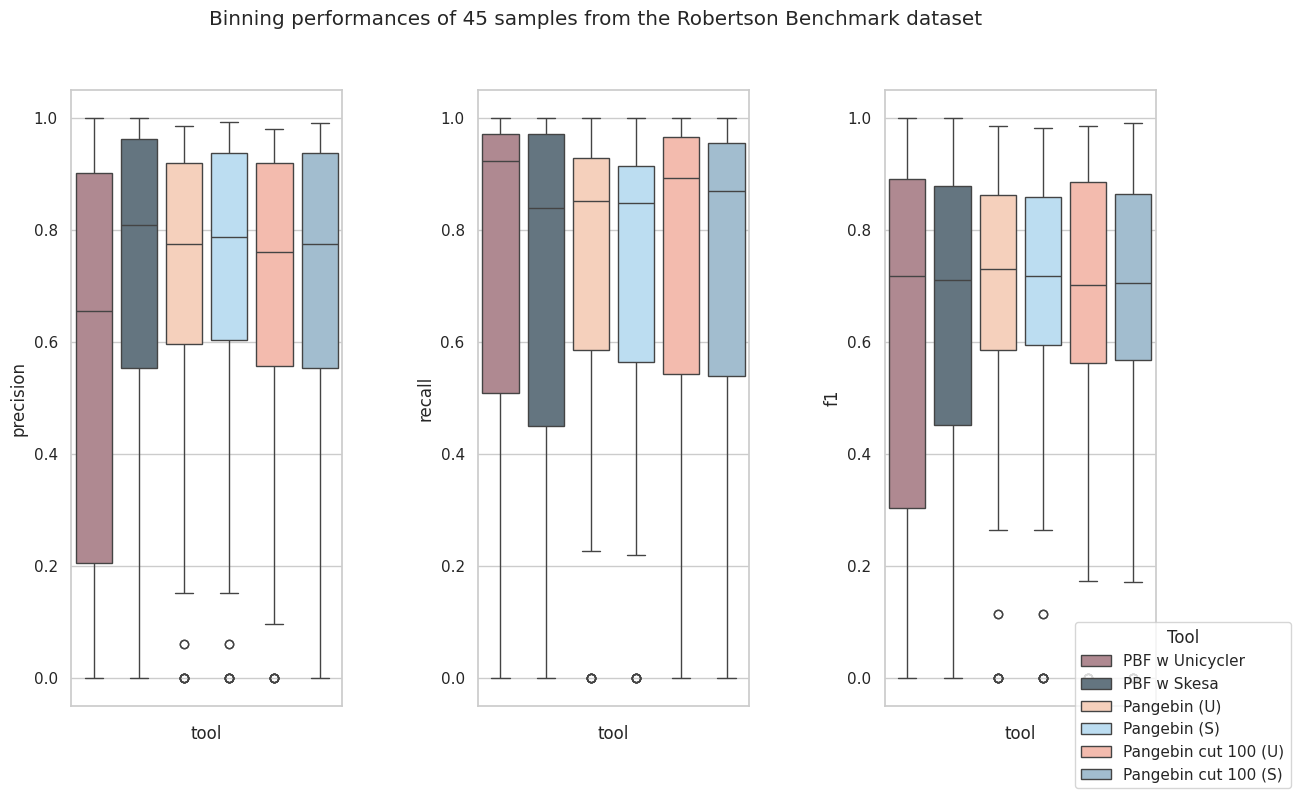

In [337]:
# mark box PLOT  using seaborn



sns.set_theme(style="whitegrid")
# color .s and .u in different colors
colors = ['#b5838d', '#5F7685', 
    '#ffcdb2', '#B3DFFA',
          '#ffb4a2', '#9ABFD6',
          '#e5989b', '#7D9BAD']

colors2 = ['#5F7685', '#b5838d',
            '#B3DFFA', '#ffcdb2',
            '#9ABFD6', '#ffb4a2',
            '#7D9BAD', '#e5989b']

          
sns.set_palette(sns.color_palette(colors))

# plt.figure(figsize=(4, 8))

# sns.boxplot(x="tool", y="precision", data=df, palette=colors)
# plt.title("Precision distribution")
# # plt.show()

# plt.figure(figsize=(4, 8))
# sns.boxplot(x="tool", y="recall", data=df, palette=colors)
# plt.title("Recall distribution")
# # plt.show()

# plt.figure(figsize=(4, 8))
# sns.boxplot(x="tool", y="f1", data=df, palette=colors)
# plt.title("F1 distribution")
# plt.show()

# put the 3 plots in the same figure
fig, axs = plt.subplots(1, 3, figsize=(14, 8))
# give a title to the fig
fig.suptitle("Binning performances of 45 samples from the Robertson Benchmark dataset")
# insert legend
# legend title
# rotate the labels of the x axis
plt.xticks(rotation=90)

plt.subplots_adjust(wspace=0.5)
sns.boxplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
# do not show x labels
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[2].set_xticklabels([])
# vertical name of columns

# axs[1].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# axs[2].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# vertical name of columns

sns.boxplot(x="tool", y="recall", data=df, palette=colors, ax=axs[1])

sns.boxplot(x="tool", y="f1", data=df, palette=colors, ax=axs[2])
fig.legend(title="Tool", labels=["PBF w Unicycler", "PBF w Skesa", "Pangebin (U)" , "Pangebin (S)", "Pangebin cut 100 (U)", "Pangebin cut 100 (S)"], loc="lower right")


plt.show()

# # same with violin plots
# fig, axs = plt.subplots(1, 3, figsize=(14, 4))
# fig.suptitle("Binning performances of 45 samples from the Robertson Benchmark dataset")

# plt.subplots_adjust(wspace=0.5)

# sns.violinplot(x="tool", y="precision", data=df, palette=colors, ax=axs[0])
# axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# axs[1].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# axs[2].set_xticklabels(axs[0].get_xticklabels(), rotation=90)


# # 0 and 1 are the max and min values of the y axis
# sns.violinplot(x="tool", y="recall", data=df, palette=colors, ax=axs[1])
# sns.violinplot(x="tool", y="f1", data=df, palette=colors, ax=axs[2])


# axs[0].set_ylim(0, 1)
# axs[1].set_ylim(0, 1)
# axs[2].set_ylim(0, 1)
# fig.legend(title="Tool", loc='lower right',  labels=["PBF w Unicycler", None , None , None ,
#                                                      "PBF w Skesa", "Pangebin (U)" , "Pangebin (S)", "Pangebin cut 100 (U)", "Pangebin cut 100 (S)"])



# plt.show()





/tmp/ipykernel_49685/4082296625.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="precision", data=df_stats, palette=colors, ax=axs[0])
/tmp/ipykernel_49685/4082296625.py:23: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.boxplot(x="tool", y="precision", data=df_stats, palette=colors, ax=axs[0])
/tmp/ipykernel_49685/4082296625.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="tool", y="recall", data=df_stats, palette=colors, ax=axs[1])
/tmp/ipykernel_49685/4082296625.py:34: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.boxplot(x="tool", y="recall", data=df_stats,

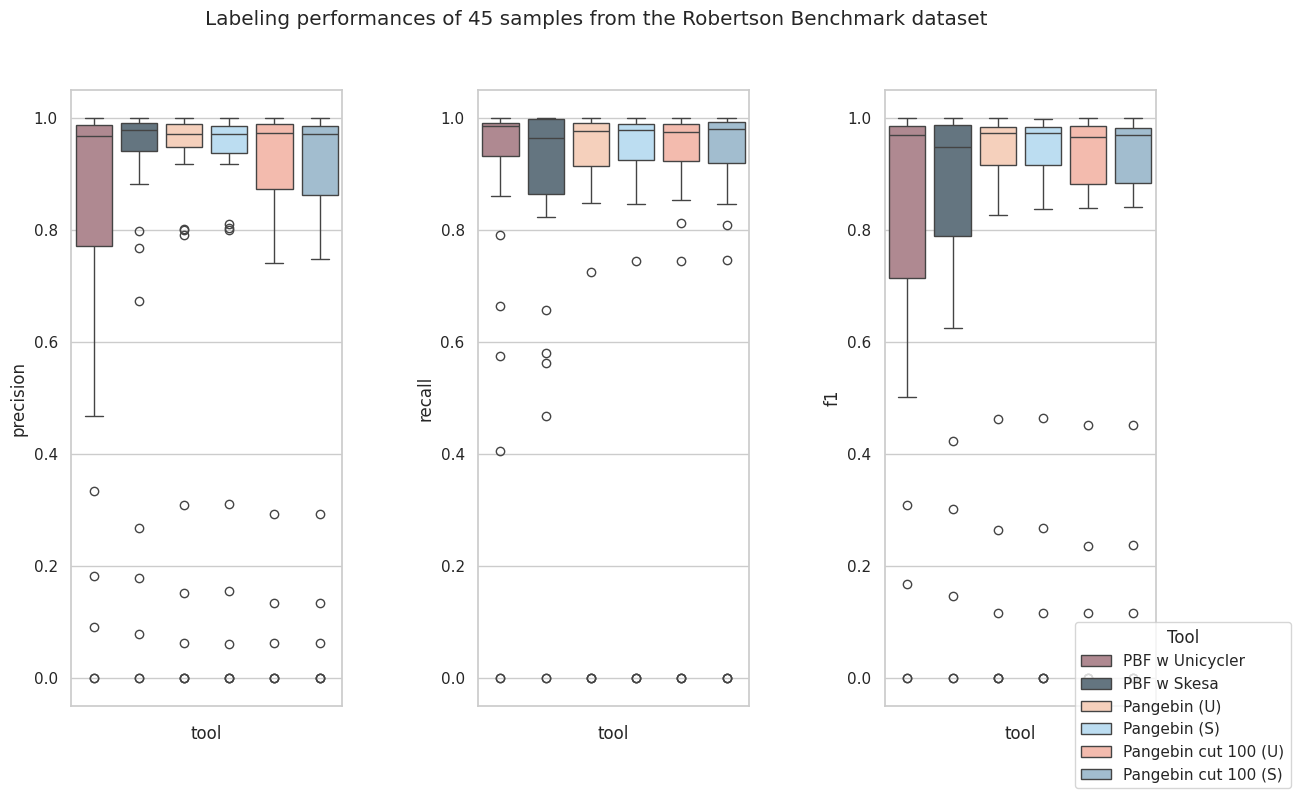

In [338]:

# box plot of the stats files
sns.set_theme(style="whitegrid")
# color .s and .u in different colors
colors = ["#9b59b6", "#3498db", "#95a5a6", "#e74c3c", "#34495e", "#2ecc71"]
colors = ['#b5838d', '#5F7685', 
    '#ffcdb2', '#B3DFFA',
          '#ffb4a2', '#9ABFD6',
          '#e5989b', '#7D9BAD']

sns.set_palette(sns.color_palette(colors))


# put the 3 plots in the same figure
fig, axs = plt.subplots(1, 3, figsize=(14, 8))
# give a title to the fig
fig.suptitle("Labeling performances of 45 samples from the Robertson Benchmark dataset")
# insert legend
# legend title
# rotate the labels of the x axis
plt.xticks(rotation=90)

plt.subplots_adjust(wspace=0.5)
sns.boxplot(x="tool", y="precision", data=df_stats, palette=colors, ax=axs[0])
# do not show x labels
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[2].set_xticklabels([])
# vertical name of columns

# axs[1].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# axs[2].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
# vertical name of columns

sns.boxplot(x="tool", y="recall", data=df_stats, palette=colors, ax=axs[1])

sns.boxplot(x="tool", y="f1", data=df_stats, palette=colors, ax=axs[2])
fig.legend(title="Tool", labels=["PBF w Unicycler", "PBF w Skesa", "Pangebin (U)" , "Pangebin (S)", "Pangebin cut 100 (U)", "Pangebin cut 100 (S)"], loc="lower right")


plt.show()


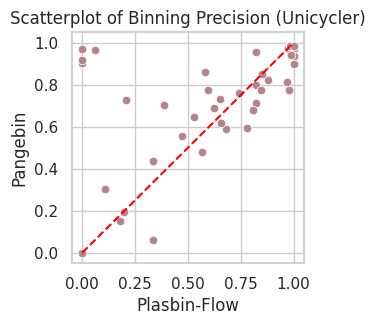

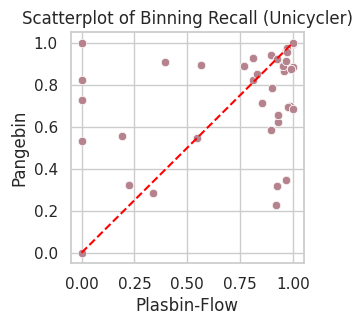

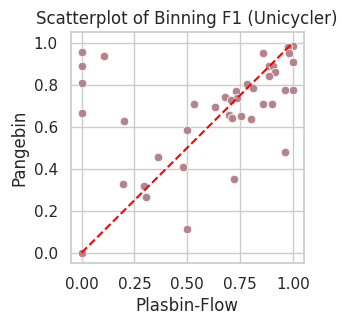

In [339]:
# Filter the dataframe for the required tools
df_u = df[df['tool'] == '0.pbf.u']
df_psm_u = df[df['tool'] == '0.pbf.psm.u']

# Merge the dataframes on the sample column
df_merged = pd.merge(df_u, df_psm_u, on='sample', suffixes=('_u', '_psm_u'))

# Plot the scatterplot
plt.figure(figsize=(3, 3))
sns.scatterplot(x='precision_u', y='precision_psm_u', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin')
plt.title('Scatterplot of Binning Precision (Unicycler)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for recall


plt.figure(figsize=(3, 3))
sns.scatterplot(x='recall_u', y='recall_psm_u', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin')
plt.title('Scatterplot of Binning Recall (Unicycler)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for f1

plt.figure(figsize=(3, 3))
sns.scatterplot(x='f1_u', y='f1_psm_u', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin')
plt.title('Scatterplot of Binning F1 (Unicycler)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()




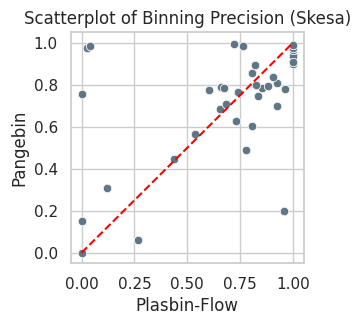

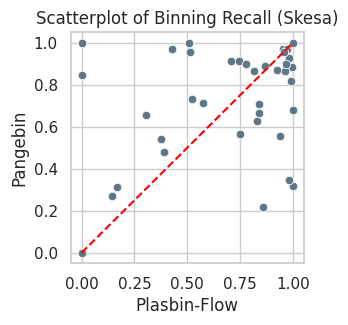

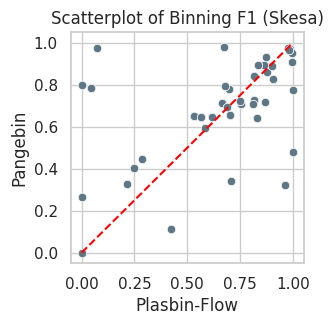

In [341]:
# Filter the dataframe for the required tools
df_u = df[df['tool'] == '0.pbf.s']
df_psm_u = df[df['tool'] == '0.pbf.psm.s']
df_psm_100_u = df[df['tool'] == '100.pbf.psm.s']

# Merge the dataframes on the sample column
df_merged = pd.merge(df_u, df_psm_u, on='sample', suffixes=('_s', '_psm_s'))
# df_merged = pd.merge(df_merged, df_psm_100_u, on='sample', suffixes=('_psm_s', '_psm_100_s'))
sns.set_palette(sns.color_palette(colors2))



# Plot the scatterplot
plt.figure(figsize=(3, 3))
sns.scatterplot(x='precision_s', y='precision_psm_s', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin')
plt.title('Scatterplot of Binning Precision (Skesa)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for recall


plt.figure(figsize=(3, 3))
sns.scatterplot(x='recall_s', y='recall_psm_s', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin')
plt.title('Scatterplot of Binning Recall (Skesa)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for f1

plt.figure(figsize=(3, 3))
sns.scatterplot(x='f1_s', y='f1_psm_s', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin')
plt.title('Scatterplot of Binning F1 (Skesa)')
# show x = y line
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.show()




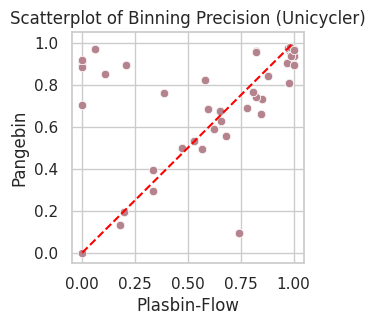

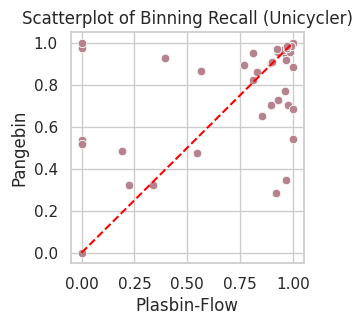

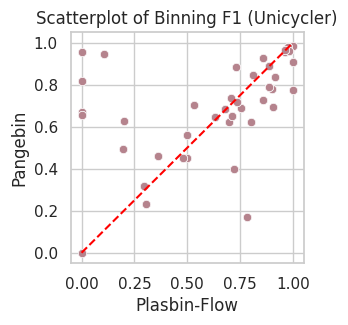

In [329]:
# Filter the dataframe for the required tools
df_u = df[df['tool'] == '0.pbf.u']
df_psm_u = df[df['tool'] == '100.pbf.psm.u']

# Merge the dataframes on the sample column
df_merged = pd.merge(df_u, df_psm_u, on='sample', suffixes=('_u', '_psm_u'))

# Plot the scatterplot
plt.figure(figsize=(3, 3))
sns.scatterplot(x='precision_u', y='precision_psm_u', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin-100')
plt.title('Scatterplot of Binning Precision (Unicycler)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for recall


plt.figure(figsize=(3, 3))
sns.scatterplot(x='recall_u', y='recall_psm_u', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin-100')
plt.title('Scatterplot of Binning Recall (Unicycler)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for f1

plt.figure(figsize=(3, 3))
sns.scatterplot(x='f1_u', y='f1_psm_u', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin-100')
plt.title('Scatterplot of Binning F1 (Unicycler)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()




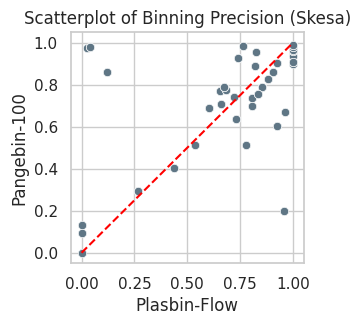

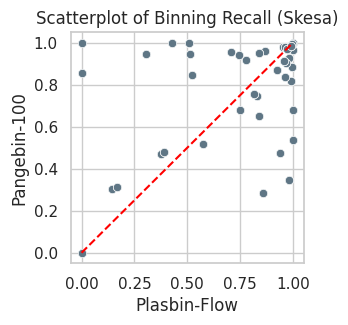

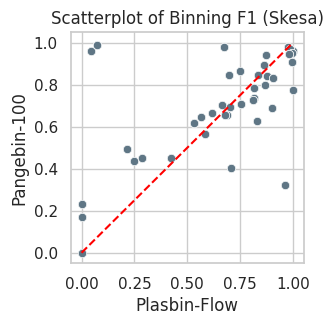

In [342]:
# Filter the dataframe for the required tools
df_u = df[df['tool'] == '0.pbf.s']
df_psm_u = df[df['tool'] == '100.pbf.psm.s']


# Merge the dataframes on the sample column
df_merged = pd.merge(df_u, df_psm_u, on='sample', suffixes=('_s', '_psm_s'))
# df_merged = pd.merge(df_merged, df_psm_100_u, on='sample', suffixes=('_psm_s', '_psm_100_s'))
sns.set_palette(sns.color_palette(colors2))



# Plot the scatterplot
plt.figure(figsize=(3, 3))
sns.scatterplot(x='precision_s', y='precision_psm_s', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin-100')
plt.title('Scatterplot of Binning Precision (Skesa)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for recall


plt.figure(figsize=(3, 3))
sns.scatterplot(x='recall_s', y='recall_psm_s', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin-100')
plt.title('Scatterplot of Binning Recall (Skesa)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.show()

# also for f1

plt.figure(figsize=(3, 3))
sns.scatterplot(x='f1_s', y='f1_psm_s', data=df_merged)
plt.xlabel('Plasbin-Flow')
plt.ylabel('Pangebin-100')
plt.title('Scatterplot of Binning F1 (Skesa)')
# show x = y line
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.show()


